In [1]:
from sklearn.metrics import accuracy_score # for calculating accuracy of model
from sklearn.model_selection import train_test_split # for splitting the dataset for training and testing
from sklearn.metrics import classification_report # for generating a classification report of model
import pickle # saving and loading trained model
from os import path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bin_data = pd.read_csv('bin_data.csv')
bin_data.drop(bin_data.columns[0],axis=1,inplace=True)
multi_data = pd.read_csv('multi_data.csv')
multi_data.drop(multi_data.columns[0],axis=1,inplace=True)
le1_classes_ = np.load('le1_classes.npy',allow_pickle=True)
le2_classes_ = np.load('le2_classes.npy',allow_pickle=True)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier
import time
import warnings
from sklearn.metrics import roc_curve,auc

In [4]:
# classifier for binary classification dataset

warnings.filterwarnings("ignore")

X = bin_data.iloc[:,0:93].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = bin_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC(gamma='auto',max_iter=300)))

print ('Model\tAcc\tpr\tRecall\tF1\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    precision = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='precision').mean()
    recall = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='recall').mean()
    f1score = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='f1_weighted').mean()
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    
    delta = time.time()- start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, precision, recall, f1score, false_alaram_rate, sensitivity, specificity, delta))
    print(cm_df)



Model	Acc	pr	Recall	F1	FAR	sen	spe	Execution_time
LR	0.970	0.964	0.980	0.970	0.023	0.965	0.977	34.93 sec
       0      1
0  11211    478
1    263  13243
LDA	0.967	0.962	0.976	0.967	0.028	0.964	0.972	52.96 sec
       0      1
0  11196    493
1    321  13185
KNN	0.985	0.984	0.988	0.985	0.012	0.987	0.988	677.55 sec
       0      1
0  11516    173
1    136  13370
CART	0.985	0.985	0.986	0.984	0.016	0.989	0.984	38.85 sec
       0      1
0  11543    146
1    187  13319
SVM	0.881	0.827	0.985	0.879	0.006	0.807	0.994	387.44 sec
      0      1
0  8478   3211
1    55  13451


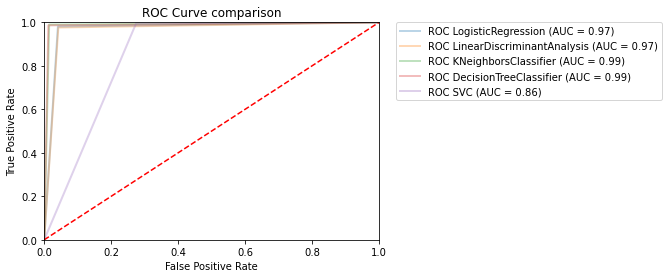

In [5]:
# Creating plot to show the ROC for all MLA
index = 1
for name, model in models:
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    fp, tp, th = roc_curve(Y_validation, predict)
    roc_auc_mla = auc(fp, tp)
    MLA_name = model.__class__.__name__
    plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
index+=1

plt.title('ROC Curve comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')    
plt.show()

In [8]:
# classifier for multi-class classification dataset

X = multi_data.iloc[:,0:93].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded, original)
y = multi_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC(gamma='auto')))

print ('Model\tAcc\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    f1score = precision_recall_fscore_support(Y_validation, predict,average='weighted')
    
    delta = time.time()- start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, false_alaram_rate, sensitivity, specificity, delta))
    print(f1score)
    print(cm_df)

Model	Acc	FAR	sen	spe	Execution_time
LR	0.944	0.049	0.910	0.951	45.58 sec
(0.9373412856072943, 0.9443937289144672, 0.9398752523979702, None)
      0     1   2  3      4
0  8747   174   0  0    195
1   451  1766   5  0    123
2     1     1   6  0    207
3     0     0   0  0     13
4    58   158  15  0  13275
LDA	0.931	0.054	0.960	0.946	9.18 sec
(0.944235213949853, 0.9314546537011312, 0.9358189916730794, None)
      0     1    2    3      4
0  8730    70    0   23    293
1   496  1684    5    2    158
2     0     0  186   18     11
3     0     0    3    9      1
4    76   111  306  154  12859
KNN	0.983	0.005	0.991	0.995	164.06 sec
(0.9845717891225582, 0.9848382615598333, 0.9846632572793769, None)
      0     1    2  3      4
0  9000    20    0  0     96
1    42  2263    0  0     40
2     0     0  192  0     23
3     0     0    2  1     10
4    69    58   20  2  13357
CART	0.983	0.004	0.991	0.996	9.96 sec
(0.9847153403756654, 0.9847191903155388, 0.9847052252988379, None)
      0     1    

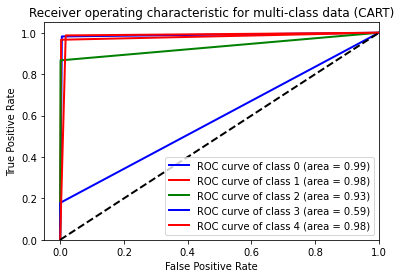

In [7]:
# roc auc plot for multiclass
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

X = multi_data.iloc[:,0:93].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data['intrusion'] # target attribute

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2,3,4])
n_classes = y.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=0)

#classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,random_state=0))

classifier = OneVsRestClassifier(DecisionTreeClassifier())

y_score = classifier.fit(X_train, y_train)
ypred = y_score.predict(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], ypred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for multi-class data (CART)')
plt.legend(loc="lower right")
plt.show()